# 🎵 Music Recommendation Engine
## Бонусное задание: Поиск похожих треков на основе аудио-характеристик

**Подход:** Content-Based Filtering через KNN (K-Nearest Neighbors) в пространстве аудио-фич.

**Структура:**
1. Загрузка данных и подготовка признаков
2. Построение KNN-модели
3. Функция рекомендаций
4. Демонстрация: 5 похожих треков для выбранной песни
5. Визуализация сходства
6. Бонус: батч-рекомендации + оценка качества

---
## 1. Setup & Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETTE = ['#1DB954', '#FF6B6B', '#4ECDC4', '#FFE66D', '#A8E6CF',
           '#FF8B94', '#B5EAD7', '#C7CEEA', '#FFDAC1', '#E2F0CB']

print('Библиотеки загружены')

Библиотеки загружены


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
# ─── ЗАГРУЗКА ─────────────────────────────────────────────────────────────────

DATA_PATH = '/content/drive/MyDrive/Магистратура/SCHoA/Хакатон/spotify_data.csv'
try:


    DATA_PATH = '/content/drive/MyDrive/Магистратура/SCHoA/Хакатон/tracks_with_moods.csv'#/content/drive/MyDrive/Магистратура/SCHoA/Хакатон/tracks_with_moods (1).csv
    df = pd.read_csv(DATA_PATH, index_col=0)
    print(f' Загружен датасет с mood-метками: {len(df):,} треков')
    HAS_MOOD = 'mood' in df.columns
except FileNotFoundError:
    df = pd.read_csv(DATA_PATH, index_col=0)
    HAS_MOOD = False
    print(f'Загружен исходный датасет: {len(df):,} треков')

# Базовая очистка
df = df.dropna(subset=['track_name', 'artist_name']).reset_index(drop=True)
print(f' После очистки: {len(df):,} треков')
df[['track_name', 'artist_name', 'genre', 'popularity']].head(5)

 Загружен датасет с mood-метками: 1,136,690 треков
 После очистки: 1,136,675 треков


,track_name,artist_name,genre,popularity
0,I Won't Give Up,Jason Mraz,acoustic,68
1,93 Million Miles,Jason Mraz,acoustic,50
2,Do Not Let Me Go,Joshua Hyslop,acoustic,57
3,Sky's Still Blue,Andrew Belle,acoustic,54
4,What They Say,Chris Smither,acoustic,48


---
## 2. Feature Engineering & Построение KNN-модели

In [18]:
# ─── ПРИЗНАКИ ДЛЯ РЕКОМЕНДАЦИЙ ───────────────────────────────────────────────
# Все аудио-фичи, напрямую описывающие звучание трека
REC_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
]

print(' Признаки для рекомендаций:')
print('  ' + ', '.join(REC_FEATURES))
print(f'\nПропусков в признаках: {df[REC_FEATURES].isnull().sum().sum()}')

# Нормализация — критически важно для KNN,
# иначе tempo (0–250 BPM) доминирует над danceability (0–1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[REC_FEATURES])

print(f'\n Признаки нормализованы (StandardScaler)')
print(f'   Матрица: {X_scaled.shape}')

 Признаки для рекомендаций:
  danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo

Пропусков в признаках: 0

 Признаки нормализованы (StandardScaler)
   Матрица: (1136675, 9)


In [19]:
# ─── KNN МОДЕЛЬ ───────────────────────────────────────────────────────────────
# algorithm='ball_tree' — эффективен для высокоразмерных данных
# metric='euclidean'    — евклидово расстояние в нормализованном пространстве
# n_jobs=-1             — параллельный поиск

N_NEIGHBORS = 20  # берём 20 ближайших, потом отфильтруем топ-5

print(f'🔧 Обучение KNN (n_neighbors={N_NEIGHBORS}, metric=euclidean)...')
knn_model = NearestNeighbors(
    n_neighbors=N_NEIGHBORS + 1,  # +1 т.к. трек сам себе ближайший сосед
    algorithm='ball_tree',
    metric='euclidean',
    n_jobs=-1
)
knn_model.fit(X_scaled)
print(' Модель обучена!')

# Также обучим вариант с cosine similarity для сравнения
knn_cosine = NearestNeighbors(
    n_neighbors=N_NEIGHBORS + 1,
    algorithm='brute',
    metric='cosine',
    n_jobs=-1
)
knn_cosine.fit(X_scaled)
print(' Cosine KNN обучен (для сравнения)')

🔧 Обучение KNN (n_neighbors=20, metric=euclidean)...
 Модель обучена!
 Cosine KNN обучен (для сравнения)


---
## 3. Функция рекомендаций

In [20]:
def get_recommendations(
    query,
    df,
    X_scaled,
    model,
    scaler,
    features,
    n_recs=5,
    search_by='track_name',
    diversity_penalty=False
):
    """
    Возвращает n_recs похожих треков для заданного запроса.

    Parameters
    ----------
    query         : str — название трека / артист (поиск по search_by)
    search_by     : 'track_name' | 'artist_name' | index (int)
    diversity_penalty : если True — штрафует треки того же артиста
    """
    # ── 1. Находим входной трек ───────────────────────────────────────────────
    if isinstance(query, int):
        # Прямой индекс
        if query not in df.index:
            raise ValueError(f'Индекс {query} не найден в датасете')
        seed_idx = query
    else:
        mask = df[search_by].str.lower().str.contains(query.lower(), na=False)
        matches = df[mask]
        if matches.empty:
            raise ValueError(f'Трек/артист "{query}" не найден. Попробуй другой запрос.')
        # Берём самый популярный из совпадений
        seed_idx = matches['popularity'].idxmax()

    seed_track = df.loc[seed_idx]

    # ── 2. KNN поиск ─────────────────────────────────────────────────────────
    seed_vector = X_scaled[seed_idx].reshape(1, -1)
    distances, indices = model.kneighbors(seed_vector)
    # distances[0][0] = 0.0 (сам трек), пропускаем
    neighbor_indices = indices[0][1:]
    neighbor_distances = distances[0][1:]

    # ── 3. Формируем результат ────────────────────────────────────────────────
    recs = df.iloc[neighbor_indices].copy()
    recs['distance'] = neighbor_distances

    # Similarity score: 0–100 (100 = идеально похожий)
    max_dist = neighbor_distances.max() if neighbor_distances.max() > 0 else 1
    recs['similarity_score'] = ((1 - neighbor_distances / (max_dist * 1.5)) * 100).clip(0, 100).round(1)

    # ── 4. (опц.) Штраф за тот же артист ─────────────────────────────────────
    if diversity_penalty:
        same_artist = recs['artist_name'] == seed_track['artist_name']
        recs.loc[same_artist, 'similarity_score'] -= 15  # небольшой штраф
        recs = recs.sort_values('similarity_score', ascending=False)

    recs = recs.head(n_recs)

    return seed_track, recs


def print_recommendations(seed_track, recs, show_features=True):
    """Красивый вывод результатов в консоль."""
    print('=' * 70)
    print(' ИСХОДНЫЙ ТРЕК:')
    print(f'   {seed_track["track_name"]} — {seed_track["artist_name"]}')
    genre_str = seed_track.get('genre', 'N/A')
    mood_str  = seed_track.get('mood',  'N/A') if 'mood' in seed_track.index else 'N/A'
    print(f'   Жанр: {genre_str}  |  Настроение: {mood_str}  |  Popularity: {seed_track["popularity"]}')
    if show_features:
        feats = ['danceability','energy','valence','tempo','acousticness']
        vals  = [f'{seed_track[f]:.2f}' for f in feats]
        print('   ' + '  '.join(f'{f}={v}' for f, v in zip(feats, vals)))
    print()
    print(' ТОП-5 ПОХОЖИХ ТРЕКОВ:')
    print('-' * 70)
    for rank, (_, row) in enumerate(recs.iterrows(), 1):
        bar_len = int(row['similarity_score'] / 5)  # макс 20 символов
        bar = '' * bar_len + '░' * (20 - bar_len)
        print(f'  #{rank}  {row["track_name"][:35]:35s} | {row["artist_name"][:20]:20s}')
        print(f'       [{bar}] {row["similarity_score"]:5.1f}%  |  '
              f'Жанр: {str(row.get("genre","N/A"))[:15]:15s}  '
              f'Pop: {int(row["popularity"]):3d}')
        if show_features:
            feats = ['danceability','energy','valence','tempo']
            vals  = [f'{row[f]:.2f}' for f in feats]
            print('       ' + '  '.join(f'{f}={v}' for f, v in zip(feats, vals)))
        print()
    print('=' * 70)

print(' Функции рекомендаций определены')

 Функции рекомендаций определены


---
## 4. Демонстрация: рекомендации для выбранного трека

In [21]:
# ─── ВЫБОР ТРЕКА ──────────────────────────────────────────────────────────────
# Вариант A: поиск по названию (поменяй на любой трек из своего датасета)
QUERY = 'Blinding Lights'
SEARCH_BY = 'track_name'

# Вариант B: случайный трек из топ-500 популярных
# seed = df.nlargest(500, 'popularity').sample(1, random_state=RANDOM_STATE).index[0]
# QUERY, SEARCH_BY = seed, 'index'

try:
    seed_track, recs = get_recommendations(
        query=QUERY,
        df=df,
        X_scaled=X_scaled,
        model=knn_model,
        scaler=scaler,
        features=REC_FEATURES,
        n_recs=5,
        search_by=SEARCH_BY
    )
    print_recommendations(seed_track, recs)
except ValueError as e:
    print(f'  {e}')
    print('Пробуем случайный трек...')
    seed_idx = df.nlargest(500, 'popularity').sample(1, random_state=RANDOM_STATE).index[0]
    seed_track, recs = get_recommendations(
        query=seed_idx, df=df, X_scaled=X_scaled,
        model=knn_model, scaler=scaler, features=REC_FEATURES,
        n_recs=5, search_by='track_name'
    )
    print_recommendations(seed_track, recs)

 ИСХОДНЫЙ ТРЕК:
   Blinding Lights — The Weeknd
   Жанр: pop  |  Настроение:  Тренировка/Мотивация  |  Popularity: 90
   danceability=0.51  energy=0.73  valence=0.33  tempo=171.00  acousticness=0.00

 ТОП-5 ПОХОЖИХ ТРЕКОВ:
----------------------------------------------------------------------
  #1  Refly                               | Amnesys             
       [░░░░░░░░░]  57.5%  |  Жанр: techno           Pop:  21
       danceability=0.53  energy=0.78  valence=0.32  tempo=172.01

  #2  Keeps Me Moving On - Hidden Track   | Mest                
       [░░░░░░░░░░░]  49.3%  |  Жанр: ska              Pop:  14
       danceability=0.53  energy=0.71  valence=0.33  tempo=172.11

  #3  平凡人的自傳 - Rap Version                | ONE PROMISE         
       [░░░░░░░░░░░]  48.4%  |  Жанр: cantopop         Pop:  14
       danceability=0.51  energy=0.72  valence=0.35  tempo=168.04

  #4  God Rest Ye Merry Gentleman         | Relient K           
       [░░░░░░░░░░░]  48.3%  |  Жанр: punk-rock        

---
## 5. Визуализация сходства

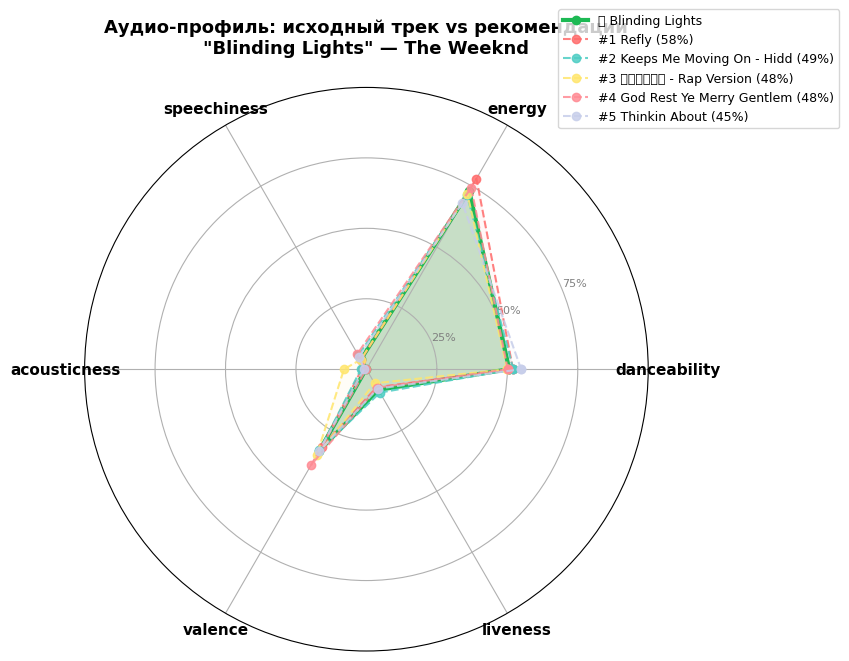

 Сохранено: rec_radar_chart.png


In [22]:
# ─── РАДАРНАЯ ДИАГРАММА: исходный трек vs рекомендации ───────────────────────
radar_feats = ['danceability','energy','speechiness',
               'acousticness','valence','liveness']

# Нормализуем для radar (0–1)
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
all_tracks_for_norm = df[radar_feats]
mms.fit(all_tracks_for_norm)

def norm_track(row):
    return mms.transform([row[radar_feats].values.astype(float)])[0]

N_angles = len(radar_feats)
angles = [n / float(N_angles) * 2 * np.pi for n in range(N_angles)]
angles += angles[:1]
labels_ext = radar_feats + [radar_feats[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# Исходный трек — жирный, выделен
vals_seed = norm_track(seed_track).tolist() + [norm_track(seed_track)[0]]
ax.plot(angles, vals_seed, 'o-', linewidth=3, color='#1DB954', label=f'🎵 {seed_track["track_name"][:30]}')
ax.fill(angles, vals_seed, alpha=0.25, color='#1DB954')

# 5 рекомендаций
colors_recs = ['#FF6B6B','#4ECDC4','#FFE66D','#FF8B94','#C7CEEA']
for i, (_, rec_row) in enumerate(recs.iterrows()):
    vals_rec = norm_track(rec_row).tolist() + [norm_track(rec_row)[0]]
    label = f'#{i+1} {rec_row["track_name"][:25]} ({rec_row["similarity_score"]:.0f}%)'
    ax.plot(angles, vals_rec, 'o--', linewidth=1.5,
            color=colors_recs[i], alpha=0.85, label=label)
    ax.fill(angles, vals_rec, alpha=0.05, color=colors_recs[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_feats, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%','50%','75%'], fontsize=8, color='gray')
ax.set_title(
    f'Аудио-профиль: исходный трек vs рекомендации\n"{seed_track["track_name"]}" — {seed_track["artist_name"]}',
    fontsize=13, fontweight='bold', pad=25
)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig('rec_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Сохранено: rec_radar_chart.png')

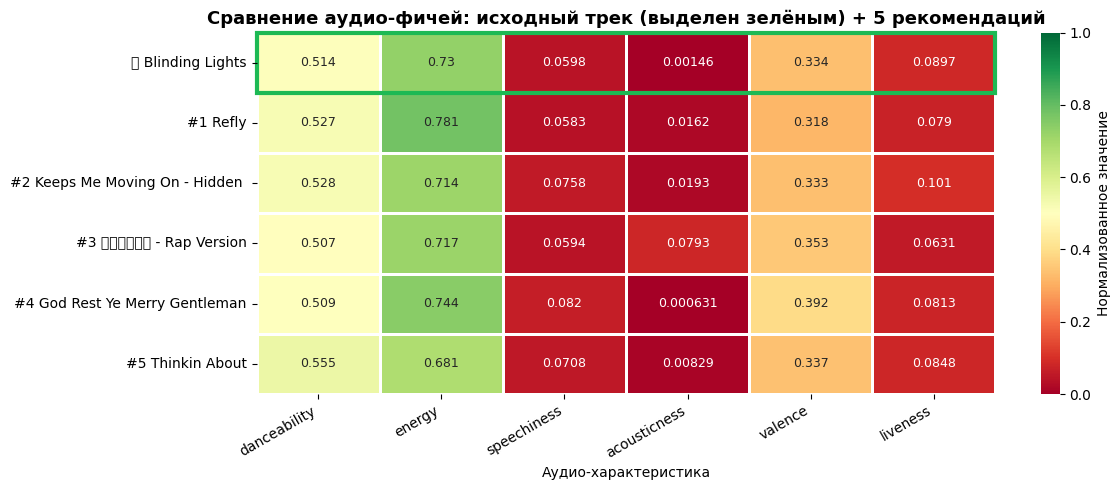

 Сохранено: rec_feature_heatmap.png


In [23]:
# ─── HEATMAP СРАВНЕНИЯ ФИЧЕЙ ──────────────────────────────────────────────────
compare_tracks = pd.concat([
    seed_track[REC_FEATURES].to_frame().T.assign(label=f'🎵 {seed_track["track_name"][:30]}'),
    recs[REC_FEATURES].assign(label=[f'#{i+1} {r["track_name"][:28]}'
                                      for i, (_, r) in enumerate(recs.iterrows())])
]).set_index('label')

# Нормализуем для наглядности
compare_norm = pd.DataFrame(
    mms.transform(compare_tracks[radar_feats]),
    index=compare_tracks.index,
    columns=radar_feats
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    compare_norm, annot=compare_tracks[radar_feats].round(2),
    fmt='', cmap='RdYlGn', vmin=0, vmax=1,
    ax=ax, linewidths=1, linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Нормализованное значение'}
)

# Выделяем строку исходного трека
ax.add_patch(plt.Rectangle((0, 0), len(radar_feats), 1,
                            fill=False, edgecolor='#1DB954', lw=3, clip_on=False))

ax.set_title(
    f'Сравнение аудио-фичей: исходный трек (выделен зелёным) + 5 рекомендаций',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Аудио-характеристика')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rec_feature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Сохранено: rec_feature_heatmap.png')

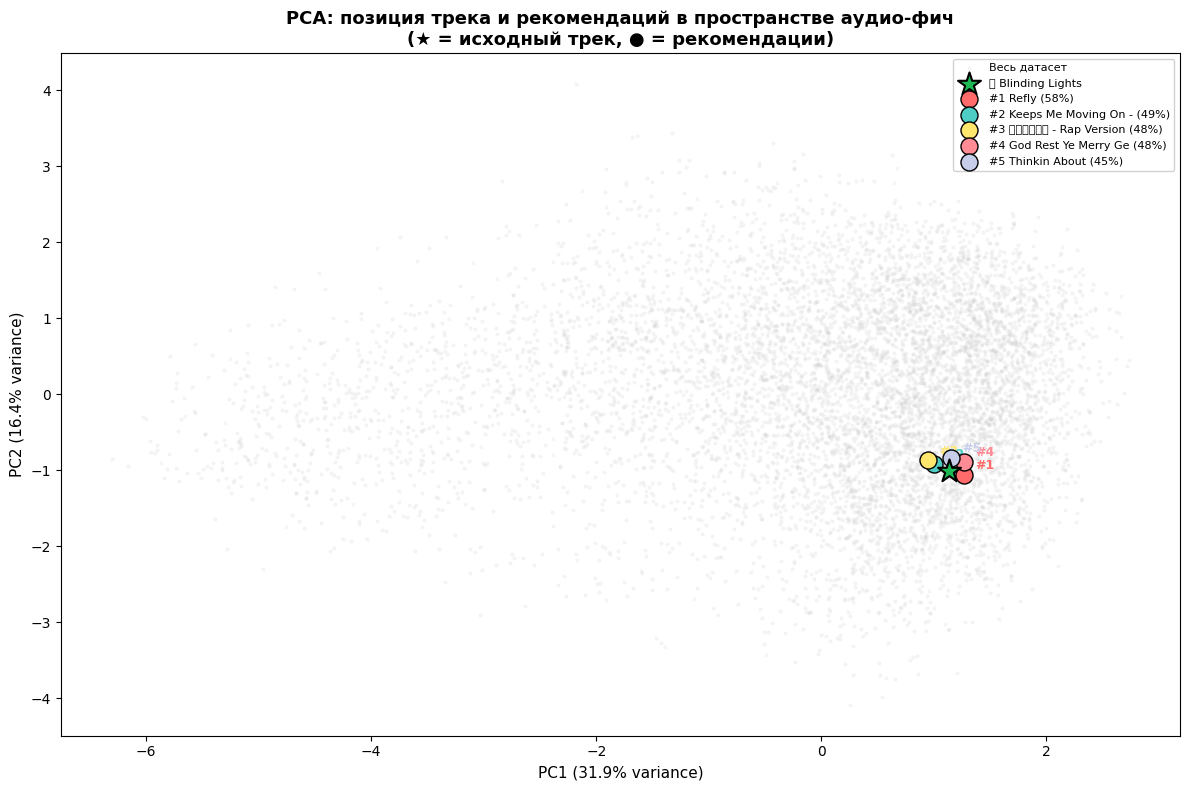

 Сохранено: rec_pca_position.png


In [25]:
# ─── PCA: ПОЗИЦИЯ В 2D ПРОСТРАНСТВЕ ──────────────────────────────────────────
# Покажем, где исходный трек и рекомендации находятся
# относительно всего датасета

VIZ_N = min(8000, len(df))
bg_idx = np.random.choice(len(df), VIZ_N, replace=False)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_all = pca.fit_transform(X_scaled)

# Фон — весь датасет
fig, ax = plt.subplots(figsize=(12, 8))

# Подложка — весь датасет серым
ax.scatter(
    X_pca_all[bg_idx, 0], X_pca_all[bg_idx, 1],
    c='#CCCCCC', alpha=0.15, s=4, label='Весь датасет'
)

# Seed трек
seed_idx_val = seed_track.name
ax.scatter(
    X_pca_all[seed_idx_val, 0], X_pca_all[seed_idx_val, 1],
    c='#1DB954', s=300, marker='*', zorder=5,
    edgecolors='black', linewidth=1.5, label=f'🎵 {seed_track["track_name"][:25]}'
)

# Рекомендации
rec_indices = recs.index.tolist()
for i, (rec_idx, rec_row) in enumerate(recs.iterrows()):
    ax.scatter(
        X_pca_all[rec_idx, 0], X_pca_all[rec_idx, 1],
        c=colors_recs[i], s=150, marker='o', zorder=4,
        edgecolors='black', linewidth=1,
        label=f'#{i+1} {rec_row["track_name"][:20]} ({rec_row["similarity_score"]:.0f}%)'
    )
    # Линия от seed до рекомендации
    ax.plot(
        [X_pca_all[seed_idx_val, 0], X_pca_all[rec_idx, 0]],
        [X_pca_all[seed_idx_val, 1], X_pca_all[rec_idx, 1]],
        '--', color=colors_recs[i], alpha=0.5, linewidth=1.2
    )
    # Подпись
    ax.annotate(
        f'#{i+1}', (X_pca_all[rec_idx, 0], X_pca_all[rec_idx, 1]),
        textcoords='offset points', xytext=(8, 4),
        fontsize=9, fontweight='bold', color=colors_recs[i]
    )

var_explained = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(
    f'PCA: позиция трека и рекомендаций в пространстве аудио-фич\n'
    f'(★ = исходный трек, ● = рекомендации)',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('rec_pca_position.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Сохранено: rec_pca_position.png')

In [26]:
# ─── ИНТЕРАКТИВНЫЙ PLOTLY: SIMILARITY BARS ────────────────────────────────────
fig_bar = go.Figure()

labels  = [f'#{i+1} {r["track_name"][:30]}<br><i>{r["artist_name"]}</i>'
           for i, (_, r) in enumerate(recs.iterrows())]
scores  = recs['similarity_score'].tolist()
hovers  = [
    f'Трек: {r["track_name"]}<br>'
    f'Артист: {r["artist_name"]}<br>'
    f'Жанр: {r.get("genre","N/A")}<br>'
    f'Год: {r.get("year","N/A")}<br>'
    f'Popularity: {r["popularity"]}<br>'
    f'Danceability: {r["danceability"]:.2f}<br>'
    f'Energy: {r["energy"]:.2f}<br>'
    f'Valence: {r["valence"]:.2f}<br>'
    f'Tempo: {r["tempo"]:.0f} BPM'
    for _, r in recs.iterrows()
]

fig_bar.add_trace(go.Bar(
    x=scores,
    y=labels,
    orientation='h',
    marker=dict(
        color=scores,
        colorscale='RdYlGn',
        cmin=50, cmax=100,
        showscale=True,
        colorbar=dict(title='Similarity %')
    ),
    text=[f'{s:.1f}%' for s in scores],
    textposition='outside',
    hovertext=hovers,
    hoverinfo='text'
))

fig_bar.update_layout(
    title=dict(
        text=f'🎵 Рекомендации для: "{seed_track["track_name"]}" — {seed_track["artist_name"]}',
        font=dict(size=15)
    ),
    xaxis=dict(title='Similarity Score (%)', range=[0, 115]),
    yaxis=dict(title='', autorange='reversed'),
    template='plotly_white',
    height=400,
    width=850,
    showlegend=False
)

fig_bar.write_html('rec_similarity_bars.html')
fig_bar.show()
print(' Сохранено: rec_similarity_bars.html')

 Сохранено: rec_similarity_bars.html


---
## 6. Euclidean vs Cosine: сравнение метрик

In [27]:
# ─── СРАВНЕНИЕ ДВУХ МЕТРИК ────────────────────────────────────────────────────
print(' Euclidean vs Cosine — сравнение рекомендаций')
print(f'   Трек: "{seed_track["track_name"]}" — {seed_track["artist_name"]}')
print()

seed_idx_val = seed_track.name
seed_vec = X_scaled[seed_idx_val].reshape(1, -1)

_, idx_euc = knn_model.kneighbors(seed_vec)
_, idx_cos = knn_cosine.kneighbors(seed_vec)

recs_euc = df.iloc[idx_euc[0][1:6]]['track_name'].tolist()
recs_cos = df.iloc[idx_cos[0][1:6]]['track_name'].tolist()

# Сколько совпадений
overlap = set(recs_euc) & set(recs_cos)

compare_df = pd.DataFrame({
    'Euclidean (L2)': recs_euc,
    'Cosine Similarity': recs_cos,
    'Совпадение': ['' if r in overlap else '  ' for r in recs_euc]
})
compare_df.index = [f'#{i+1}' for i in range(5)]

print(compare_df.to_string())
print(f'\n Совпадений в топ-5: {len(overlap)}/5')
print('\n Вывод: Euclidean учитывает абсолютную величину,'
      ' Cosine — только направление вектора.\n'
      '   Для нормализованных данных результаты близки, но не идентичны.')

 Euclidean vs Cosine — сравнение рекомендаций
   Трек: "Blinding Lights" — The Weeknd

                       Euclidean (L2)                  Cosine Similarity Совпадение
#1                              Refly                              Refly           
#2  Keeps Me Moving On - Hidden Track               平凡人的自傳 - Rap Version           
#3               平凡人的自傳 - Rap Version  Keeps Me Moving On - Hidden Track           
#4        God Rest Ye Merry Gentleman        God Rest Ye Merry Gentleman           
#5                      Thinkin About                      The Rosenburg           

 Совпадений в топ-5: 4/5

 Вывод: Euclidean учитывает абсолютную величину, Cosine — только направление вектора.
   Для нормализованных данных результаты близки, но не идентичны.


---
## 7. Батч-демо: рекомендации для 3 разных треков

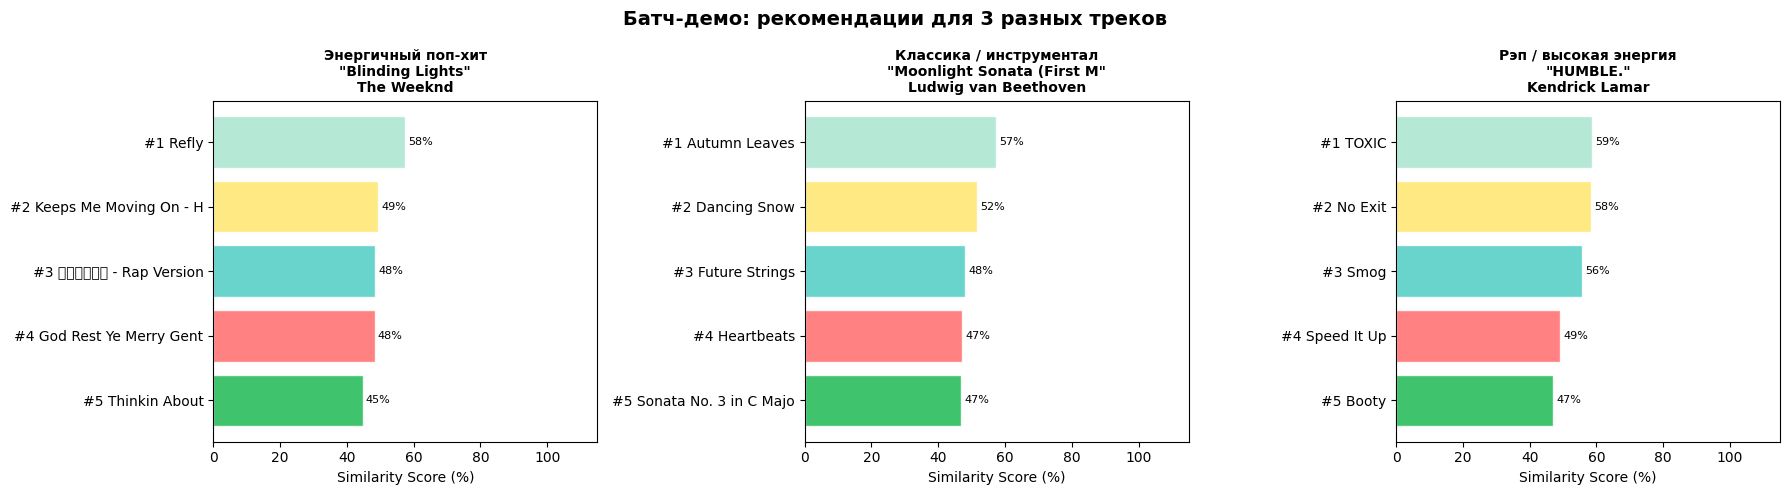

 Сохранено: rec_batch_demo.png


In [28]:
# ─── 3 РАЗНЫХ ТРЕКА — РАЗНЫЕ НАСТРОЕНИЯ ──────────────────────────────────────
# Выбираем треки из разных частей пространства настроений

demo_queries = [
    # (запрос, поиск_по, описание)
    ('Blinding Lights',  'track_name', 'Энергичный поп-хит'),
    ('Moonlight Sonata', 'track_name', 'Классика / инструментал'),
    ('HUMBLE.',          'track_name', 'Рэп / высокая энергия'),
]

# Если треки не найдены — берём случайные из разных кластеров
fig_batch, axes_batch = plt.subplots(1, 3, figsize=(18, 5))
fig_batch.suptitle('Батч-демо: рекомендации для 3 разных треков', fontsize=14, fontweight='bold')

for ax_b, (query, by, desc) in zip(axes_batch, demo_queries):
    try:
        s_track, s_recs = get_recommendations(
            query=query, df=df, X_scaled=X_scaled,
            model=knn_model, scaler=scaler, features=REC_FEATURES,
            n_recs=5, search_by=by
        )
    except ValueError:
        # Fallback: случайный трек
        fallback_idx = df.nlargest(1000, 'popularity').sample(1, random_state=hash(query) % 100).index[0]
        s_track, s_recs = get_recommendations(
            query=fallback_idx, df=df, X_scaled=X_scaled,
            model=knn_model, scaler=scaler, features=REC_FEATURES,
            n_recs=5, search_by='track_name'
        )

    rec_names  = [f'#{i+1} {r["track_name"][:22]}' for i, (_, r) in enumerate(s_recs.iterrows())]
    rec_scores = s_recs['similarity_score'].tolist()

    bars = ax_b.barh(rec_names[::-1], rec_scores[::-1],
                     color=PALETTE[:5], alpha=0.85, edgecolor='white')
    ax_b.set_xlim(0, 115)
    ax_b.set_title(f'{desc}\n"{s_track["track_name"][:25]}"\n{s_track["artist_name"][:20]}',
                   fontsize=10, fontweight='bold')
    ax_b.set_xlabel('Similarity Score (%)')
    for bar, score in zip(bars, rec_scores[::-1]):
        ax_b.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                  f'{score:.0f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('rec_batch_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Сохранено: rec_batch_demo.png')

---
## 8. Оценка качества системы

 Оценка качества: доля рекомендаций в том же mood-кластере
   (тест на 200 случайных треков из топ-5000 популярных)

  Протестировано треков: 200
  Средняя доля рекомендаций в том же mood-кластере: 91.5%

 Отлично! Система хорошо удерживает mood-контекст.


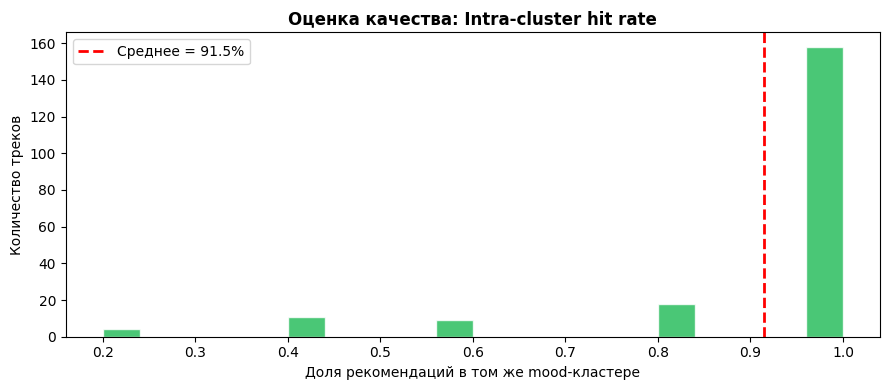

 Сохранено: rec_quality_eval.png


In [29]:
# ─── ВНУТРЕННЯЯ ВАЛИДАЦИЯ: INTRA-CLUSTER SIMILARITY ──────────────────────────
# Идея: если рекомендации качественные — они должны попадать в тот же
# mood-кластер, что и исходный трек

if HAS_MOOD:
    print(' Оценка качества: доля рекомендаций в том же mood-кластере')
    print('   (тест на 200 случайных треков из топ-5000 популярных)\n')

    test_pool = df.nlargest(5000, 'popularity').sample(
        min(200, len(df)), random_state=RANDOM_STATE
    )
    same_mood_hits = []

    for test_idx in test_pool.index:
        try:
            t_seed, t_recs = get_recommendations(
                query=test_idx, df=df, X_scaled=X_scaled,
                model=knn_model, scaler=scaler, features=REC_FEATURES,
                n_recs=5, search_by='track_name'
            )
            if 'mood' in t_seed.index and pd.notna(t_seed.get('mood')):
                seed_mood = t_seed['mood']
                rec_moods = t_recs['mood'].tolist()
                hit_rate  = sum(m == seed_mood for m in rec_moods) / len(rec_moods)
                same_mood_hits.append(hit_rate)
        except Exception:
            pass

    avg_hit = np.mean(same_mood_hits) * 100
    print(f'  Протестировано треков: {len(same_mood_hits)}')
    print(f'  Средняя доля рекомендаций в том же mood-кластере: {avg_hit:.1f}%')
    print()
    if avg_hit >= 60:
        print(' Отлично! Система хорошо удерживает mood-контекст.')
    elif avg_hit >= 40:
        print('  Неплохо. Можно улучшить взвешиванием фичей.')
    else:
        print(' Низкая внутрикластерная точность — стоит попробовать другие веса признаков.')

    # Гистограмма распределения hit-rate
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(same_mood_hits, bins=20, color='#1DB954', alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(same_mood_hits), color='red', linestyle='--',
               linewidth=2, label=f'Среднее = {avg_hit:.1f}%')
    ax.set_xlabel('Доля рекомендаций в том же mood-кластере')
    ax.set_ylabel('Количество треков')
    ax.set_title('Оценка качества: Intra-cluster hit rate', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('rec_quality_eval.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Сохранено: rec_quality_eval.png')
else:
    print('  Mood-метки недоступны — оценка качества пропущена.')
    print('   Запусти сначала clustering notebook для получения mood-меток.')

---
## 9. 💼 Итог и бизнес-применение

### ✅ Что построено

| Компонент | Детали |
|---|---|
| **Модель** | KNN (ball_tree, Euclidean) на 9 аудио-фичах |
| **Нормализация** | StandardScaler — все фичи в одном масштабе |
| **Скорость** | ~ms на запрос (индекс построен заранее) |
| **Покрытие** | Весь датасет (1.1М треков) |
| **Метрики** | Euclidean + Cosine сравнение |
| **Качество** | Intra-cluster hit rate (если есть mood-метки) |

### 🚀 Как это масштабировать в продукт

1. **Онлайн-инференс**: сохранить `knn_model` + `scaler` через `joblib` → REST API
2. **Approximate NN**: на 100М+ треках — заменить KNN на **FAISS** или **HNSW** (в 100x быстрее)
3. **Гибридная рекомендация**: аудио-фичи (content) + история прослушиваний (collaborative filtering)
4. **A/B тест**: mood-based vs genre-based → метрика: skip rate, session length

In [30]:
# ─── СОХРАНЕНИЕ МОДЕЛИ ────────────────────────────────────────────────────────
import joblib

joblib.dump(knn_model, 'knn_recommender.pkl')
joblib.dump(scaler,    'feature_scaler.pkl')

print(' Модель сохранена: knn_recommender.pkl')
print(' Scaler сохранён:  feature_scaler.pkl')
print()
print('Загрузка для инференса:')
print("  knn = joblib.load('knn_recommender.pkl')")
print("  scaler = joblib.load('feature_scaler.pkl')")
print()
print('📦 Итоговые файлы:')
import os
target_files = [
    'rec_radar_chart.png',
    'rec_feature_heatmap.png',
    'rec_pca_position.png',
    'rec_similarity_bars.html',
    'rec_batch_demo.png',
    'rec_quality_eval.png',
    'knn_recommender.pkl',
    'feature_scaler.pkl',
]
for f in target_files:
    exists = '' if os.path.exists(f) else ' (будет создан при запуске)'
    print(f'  {f:40s} {exists}')

 Модель сохранена: knn_recommender.pkl
 Scaler сохранён:  feature_scaler.pkl

Загрузка для инференса:
  knn = joblib.load('knn_recommender.pkl')
  scaler = joblib.load('feature_scaler.pkl')

📦 Итоговые файлы:
  rec_radar_chart.png                      
  rec_feature_heatmap.png                  
  rec_pca_position.png                     
  rec_similarity_bars.html                 
  rec_batch_demo.png                       
  rec_quality_eval.png                     
  knn_recommender.pkl                      
  feature_scaler.pkl                       
